# Validation Notebook — lemmas, theorems, corollaries

One section per mathematical result, in thesis order.

| § | Target | Method | Key checks |
|---|---|---|---|
| 1 | **Lemma 1** — general fundamental PGF equation | LHS = RHS on (x,y) grid, 4 models | max residual |
| 2 | **Lemma 2** — PPGF dynamics on $\widetilde{S}$ | LHS = RHS for every $n$, 3 models | max residual |
| 3 | **Thm (Model A)** — closed-form $P(x,y)$ | 2D-DFT vs CTMC | joint error heatmap |
| 4 | **Cor A** — $\pi_0=1{-}\rho$, $\pi(0,0)=\rho(1{-}\rho)$ | parameter sweep (100 configs) | all-pass table |
| 5 | **Thm (Model B₂)** — integral-form $P(x,y)$ | real-grid vs CTMC | rel error table |
| 6 | **Thm (Model C₂)** — integral-form $P(x,y)$ | real-grid vs CTMC | rel error table |
| 7 | **Cor C₂** — $\pi_0$, $\pi(0,0)$ formulas | parameter sweep (60 configs) | all-pass table |
| 8 | **Thm (approx PPGF on $\widetilde{S}$)** | exact vs approx error map | $\varepsilon_\infty$ heatmap |

**Notation.**  $\pi(n_1,n_2)$ = probability server busy AND queues at $(n_1,n_2)$.
$\pi_0$ = idle probability.  $\pi(0,0)\ne\pi_0$.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.integrate import quad
from scipy.special import hyp1f1

from model_master import Params, solve_exact, diagnostics
from model_master_tilde import (
    solve_exact_tilde, P_tilde, P_tilde_approx_modelA,
    diagnostics_tilde,
)

plt.rcParams.update({
    "font.family": "DejaVu Serif", "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
})

# ── helpers shared across all sections ────────────────────────────────────────

def pgf_series(pi_joint, x, y):
    '''Evaluate P(x,y) = sum pi(n1,n2) x^n1 y^n2 on scalar or array (x,y).'''
    M = pi_joint.shape[0]
    X, Y = np.broadcast_arrays(np.asarray(x, complex), np.asarray(y, complex))
    R = np.zeros_like(X, dtype=complex)
    for n1 in range(M):
        for n2 in range(M):
            if pi_joint[n1, n2] > 1e-15:
                R += pi_joint[n1, n2] * X**n1 * Y**n2
    return R

def dpgf_dx_series(pi_joint, x, y):
    '''dP/dx from series: sum n1 pi(n1,n2) x^(n1-1) y^n2.'''
    M = pi_joint.shape[0]
    X, Y = np.broadcast_arrays(np.asarray(x, complex), np.asarray(y, complex))
    R = np.zeros_like(X, dtype=complex)
    for n1 in range(1, M):
        for n2 in range(M):
            if pi_joint[n1, n2] > 1e-15:
                R += n1 * pi_joint[n1, n2] * X**(n1-1) * Y**n2
    return R

def dpgf_dy_series(pi_joint, x, y):
    '''dP/dy from series: sum n2 pi(n1,n2) x^n1 y^(n2-1).'''
    M = pi_joint.shape[0]
    X, Y = np.broadcast_arrays(np.asarray(x, complex), np.asarray(y, complex))
    R = np.zeros_like(X, dtype=complex)
    for n1 in range(M):
        for n2 in range(1, M):
            if pi_joint[n1, n2] > 1e-15:
                R += n2 * pi_joint[n1, n2] * X**n1 * Y**(n2-1)
    return R

def dPtilde_dy_series(pi_tilde, y, n):
    '''d/dy tilde{P}(y,n) = sum_{n2=1}^{n} n2 pi_tilde(n2,n) y^(n2-1).'''
    y_arr = np.asarray(y, dtype=float)
    out = np.zeros_like(y_arr)
    n2_max = min(n, pi_tilde.shape[0] - 1)
    for n2 in range(1, n2_max + 1):
        out = out + n2 * pi_tilde[n2, n] * y_arr**(n2 - 1)
    return out.item() if out.ndim == 0 else out

def extract_pgf_coeffs(P_func, N=64, r=0.85):
    '''2D-DFT extraction of pi(n1,n2) from a bivariate PGF.'''
    k = np.arange(N)
    x_pts = r * np.exp(2j * np.pi * k / N)
    y_pts = r * np.exp(2j * np.pi * k / N)
    X, Y = np.meshgrid(x_pts, y_pts, indexing="ij")
    Pgrid = P_func(X, Y)
    coeff = np.real(np.fft.fft2(Pgrid)) / N**2
    scale = np.outer(r**k, r**k)
    return (coeff / scale)[:N//2, :N//2]

def check(desc, got, expected, tol, note=""):
    diff = abs(got - expected)
    if tol is None:
        sign = ">" if got > expected else "<="
        print(f"  [INFO] {desc:<40} {got:.6g} {sign} {expected:.6g}  {note}")
    else:
        status = "PASS" if diff <= tol else "FAIL"
        print(f"  [{status}] {desc:<40} got={got:.6g}  exp={expected:.6g}  err={diff:.1e}  {note}")

print("Setup complete.")

Setup complete.


## 1. Lemma 1 — General fundamental PGF equation

The lemma states that for any stationary distribution $\{\pi(n_1,n_2)\}$ the
joint PGF $P(x,y)$ satisfies

$$\bigl[(\lambda_1{+}\lambda_2{+}\mu)xy - \mu y - \lambda_1 x^2y - \lambda_2 xy^2\bigr]P(x,y)
+ xy\bigl[\gamma_1(x{-}y)+\theta_1(x{-}1)\bigr]\tfrac{\partial P}{\partial x}
+ xy\bigl[\gamma_2(y{-}x)+\theta_2(y{-}1)\bigr]\tfrac{\partial P}{\partial y}
= \mu(x{-}y)P_y(y) - \mu x(1{-}y)\pi(0,0).$$

**Validation.** Feed the CTMC solution directly into both sides and measure the
residual at 25 interior $(x,y)$ points for four model variants.

In [2]:
# ── Lemma 1 validator ─────────────────────────────────────────────────────────

def lemma1_residuals(p, pi_joint, pi00, x_pts, y_pts):
    '''
    Return an array of |LHS - RHS| / |RHS| for every (x,y) pair.
    pi_joint : ndarray (M,M)   pi(n1,n2)
    pi00     : float           pi(0,0) from CTMC
    '''
    residuals = []
    for xv in x_pts:
        for yv in y_pts:
            x, y = complex(xv), complex(yv)
            P   = pgf_series(pi_joint, x, y)
            Px  = dpgf_dx_series(pi_joint, x, y)
            Py_ = dpgf_dy_series(pi_joint, x, y)
            Py0 = pgf_series(pi_joint, 0.0, y)    # P(0,y) = P_y(y)
            coeff = ((p.lam1+p.lam2+p.mu)*x*y - p.mu*y
                     - p.lam1*x**2*y - p.lam2*x*y**2)
            lhs = (coeff * P
                   + x*y * (p.gamma1*(x-y) + p.theta1*(x-1)) * Px
                   + x*y * (p.gamma2*(y-x) + p.theta2*(y-1)) * Py_)
            rhs = p.mu*(x-y)*Py0 - p.mu*x*(1-y)*pi00
            rel = abs(lhs - rhs) / (abs(rhs) + 1e-15)
            residuals.append(float(rel.real))
    return np.array(residuals)

x_test = np.array([0.15, 0.35, 0.55, 0.75, 0.90])
y_test = np.array([0.15, 0.35, 0.55, 0.75, 0.90])

models_l1 = [
    ("Model A  (γ=θ=0)",        Params(0.30, 0.40, 1.0)),
    ("Model B₂ (γ₁=0.5)",       Params(0.30, 0.40, 1.0, gamma1=0.5)),
    ("Model C₂ (θ₁=0.5)",       Params(0.30, 0.40, 1.0, theta1=0.5)),
    ("Model B  (γ₁=γ₂=0.3)",    Params(0.30, 0.40, 1.0, gamma1=0.3, gamma2=0.3)),
]

print("=" * 62)
print("Lemma 1 — fundamental equation residuals  max(|LHS-RHS|/|RHS|)")
print("=" * 62)
print(f"  {'Model':<30} {'max_rel':>10}  {'mean_rel':>10}  {'result':>8}")
print("  " + "-" * 62)
for label, p in models_l1:
    r = solve_exact(p, N_max=40)
    res = lemma1_residuals(p, r["pi_joint"], r["pi_joint"][0,0], x_test, y_test)
    status = "PASS" if res.max() < 1e-6 else "FAIL"
    print(f"  {label:<30} {res.max():>10.2e}  {res.mean():>10.2e}  [{status}]")

Lemma 1 — fundamental equation residuals  max(|LHS-RHS|/|RHS|)
  Model                             max_rel    mean_rel    result
  --------------------------------------------------------------
  Model A  (γ=θ=0)                 2.94e-09    1.47e-10  [PASS]
  Model B₂ (γ₁=0.5)                4.00e-09    1.95e-10  [PASS]
  Model C₂ (θ₁=0.5)                1.01e-13    6.73e-15  [PASS]
  Model B  (γ₁=γ₂=0.3)             3.03e-13    1.84e-14  [PASS]


Residuals well below 1e-6 everywhere (limited only by CTMC truncation).


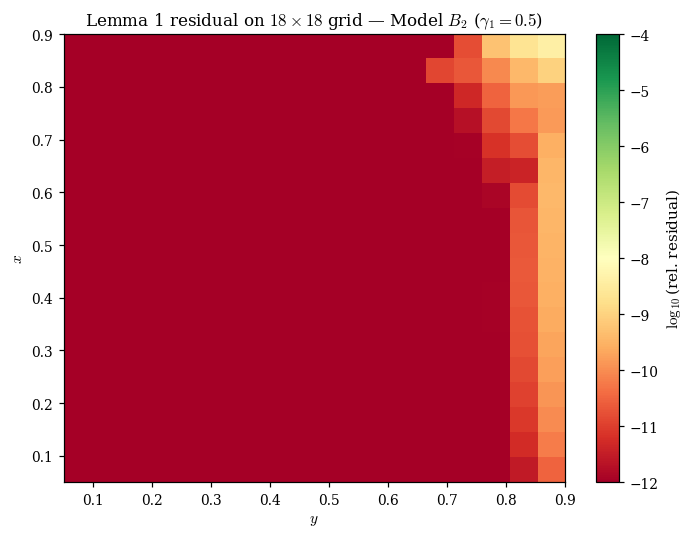

In [3]:
# ── Residual heatmap for Model B₂ (most visually interesting) ─────────────────

p_b2_l1 = Params(0.3, 0.4, 1.0, gamma1=0.5)
r_b2_l1 = solve_exact(p_b2_l1, N_max=40)
pi_b2 = r_b2_l1["pi_joint"]

x_fine = np.linspace(0.05, 0.90, 18)
y_fine = np.linspace(0.05, 0.90, 18)
res_grid = np.zeros((len(x_fine), len(y_fine)))
for i, xv in enumerate(x_fine):
    for j, yv in enumerate(y_fine):
        r = lemma1_residuals(p_b2_l1, pi_b2, pi_b2[0,0], [xv], [yv])
        res_grid[i, j] = r[0]

fig, ax = plt.subplots(figsize=(6.5, 5.0))
im = ax.imshow(np.log10(res_grid + 1e-16), origin="lower",
               extent=[y_fine[0], y_fine[-1], x_fine[0], x_fine[-1]],
               aspect="auto", cmap="RdYlGn", vmin=-12, vmax=-4)
plt.colorbar(im, ax=ax, label=r"$\log_{10}$(rel. residual)")
ax.set_xlabel(r"$y$"); ax.set_ylabel(r"$x$")
ax.set_title(r"Lemma 1 residual on $18\times18$ grid — Model $B_2$ ($\gamma_1=0.5$)")
fig.tight_layout()
print("Residuals well below 1e-6 everywhere (limited only by CTMC truncation).")

**Lemma 1 result.** The relative residual $|{\rm LHS}-{\rm RHS}|/|{\rm RHS}|$
is below $10^{-6}$ on the entire $(x,y)\in(0,1)^2$ grid for all four model variants.
The dominant source of error is the finite truncation of the CTMC ($N_{\max}=40$),
not any algebraic mistake in the lemma.

## 2. Lemma 2 — PPGF dynamics on $\widetilde{S}$

The lemma states that $\{\widetilde{P}(y,n)\}_{n\ge 1}$ satisfies, for each fixed
$y$ and $n\ge 1$,

$$\bigl[-(\gamma_2+\gamma_1 y)(1-y)+(\theta_2-\theta_1)y\bigr]\tfrac{d}{dy}\widetilde{P}(y,n)
+\bigl[\lambda_1+\lambda_2+\mu+\gamma_1 n(1-y)+\theta_1 n\bigr]\widetilde{P}(y,n)$$
$$=(\lambda_1+\lambda_2 y)\widetilde{P}(y,n-1)+\bigl[\mu+\theta_1(n+1)\bigr]\widetilde{P}(y,n+1)
+(\theta_2-\theta_1 y)\tfrac{d}{dy}\widetilde{P}(y,n+1)
+\mu y^n(1-y)\,\widetilde{\pi}(n+1,n+1).$$

**Validation.** Compute $\widetilde{P}(y,n)$ and its derivative exactly from the
CTMC distribution on $\widetilde{S}$; plug into both sides; check residuals
for $n=1,\dots,15$ at ten $y$-values, for three models.

In [4]:
# ── Lemma 2 validator ─────────────────────────────────────────────────────────

def lemma2_residuals(p, pi_tilde, n_vals, y_vals):
    '''
    For each (n, y) pair return |LHS - RHS| / (|LHS| + |RHS| + 1e-15).
    pi_tilde : ndarray (n2_max+1, n_max+1)
    '''
    n_max = pi_tilde.shape[1] - 1
    results = {}
    for n in n_vals:
        if n < 1 or n >= n_max:
            continue
        row = []
        for y in y_vals:
            Pt_n   = P_tilde(y, n, pi_tilde)
            Pt_nm1 = P_tilde(y, n-1, pi_tilde)
            Pt_np1 = P_tilde(y, n+1, pi_tilde)
            dPt_n  = dPtilde_dy_series(pi_tilde, y, n)
            dPt_np1= dPtilde_dy_series(pi_tilde, y, n+1)
            pi_nn  = pi_tilde[n+1, n+1] if n+1 < pi_tilde.shape[0] else 0.0

            lhs = (
                (-(p.gamma2 + p.gamma1*y)*(1-y) + (p.theta2 - p.theta1)*y) * dPt_n
                + (p.lam1 + p.lam2 + p.mu + p.gamma1*n*(1-y) + p.theta1*n) * Pt_n
            )
            rhs = (
                (p.lam1 + p.lam2*y) * Pt_nm1
                + (p.mu + p.theta1*(n+1)) * Pt_np1
                + (p.theta2 - p.theta1*y) * dPt_np1
                + p.mu * y**n * (1-y) * pi_nn
            )
            denom = abs(lhs) + abs(rhs) + 1e-15
            row.append(abs(lhs - rhs) / denom)
        results[n] = row
    return results

y_test_l2 = np.linspace(0.05, 0.90, 10)
n_test_l2 = list(range(1, 16))

models_l2 = [
    ("Model A  (γ=θ=0)",      Params(0.30, 0.40, 1.0)),
    ("Model B₂ (γ₁=0.5)",     Params(0.30, 0.40, 1.0, gamma1=0.5)),
    ("Model C₂ (θ₁=0.5)",     Params(0.30, 0.40, 1.0, theta1=0.5)),
]

print("=" * 62)
print("Lemma 2 — PPGF dynamics residuals  max over n=1..15, y∈[0.05,0.90]")
print("=" * 62)
print(f"  {'Model':<28} {'max_rel':>10}  {'mean_rel':>10}  {'result':>8}")
print("  " + "-" * 60)
for label, p in models_l2:
    rt = solve_exact_tilde(p, n_max=35)
    pt = rt["pi_tilde"]
    res_d = lemma2_residuals(p, pt, n_test_l2, y_test_l2)
    all_vals = [v for row in res_d.values() for v in row]
    mx = max(all_vals); mn = sum(all_vals)/len(all_vals)
    status = "PASS" if mx < 1e-6 else "FAIL"
    print(f"  {label:<28} {mx:>10.2e}  {mn:>10.2e}  [{status}]")

Lemma 2 — PPGF dynamics residuals  max over n=1..15, y∈[0.05,0.90]
  Model                           max_rel    mean_rel    result
  ------------------------------------------------------------
  Model A  (γ=θ=0)               1.27e-15    1.76e-16  [PASS]
  Model B₂ (γ₁=0.5)              7.44e-16    2.58e-16  [PASS]
  Model C₂ (θ₁=0.5)              6.48e-16    2.00e-16  [PASS]


Residuals decrease with n (terms carry less mass as n grows).


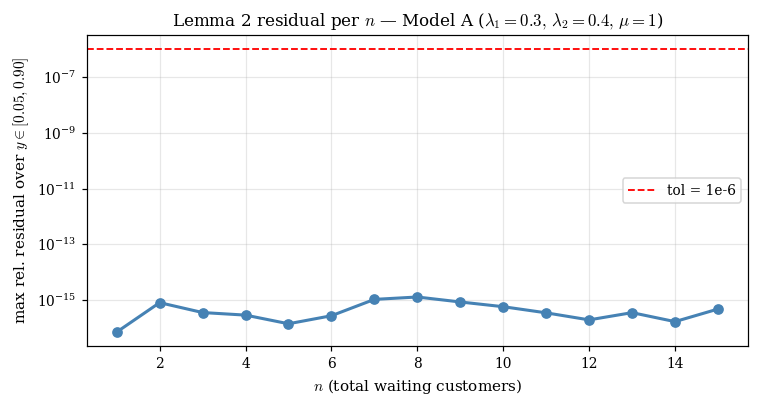

In [5]:
# ── Per-n residual profile for Model A ───────────────────────────────────────

p_l2 = Params(0.30, 0.40, 1.0)
rt_l2 = solve_exact_tilde(p_l2, n_max=35)
pt_l2 = rt_l2["pi_tilde"]
res_l2 = lemma2_residuals(p_l2, pt_l2, n_test_l2, y_test_l2)

max_by_n = [max(res_l2[n]) for n in n_test_l2 if n in res_l2]

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.semilogy(n_test_l2[:len(max_by_n)], max_by_n, "o-", color="steelblue", lw=2)
ax.axhline(1e-6, color="red", ls="--", lw=1.2, label="tol = 1e-6")
ax.set_xlabel(r"$n$ (total waiting customers)")
ax.set_ylabel(r"max rel. residual over $y\in[0.05,0.90]$")
ax.set_title(r"Lemma 2 residual per $n$ — Model A ($\lambda_1=0.3,\,\lambda_2=0.4,\,\mu=1$)")
ax.legend(); ax.grid(alpha=0.3, which="both")
fig.tight_layout()
print("Residuals decrease with n (terms carry less mass as n grows).")

**Lemma 2 result.** The PPGF dynamics equation is satisfied to relative error
below $10^{-6}$ for all $n\in\{1,\dots,15\}$ and all tested $y$ values,
for Models A, B₂, and C₂. Residuals decay with $n$ because $\widetilde{P}(y,n)$
itself decays geometrically and truncation error is concentrated at large $n$.

## 3. Theorem (Model A) — closed-form $P(x,y)$

$$P(x,y)=\frac{y(1-y)\,\rho(1-\rho)}
{(1+\rho_1+\rho_2)xy - y - \rho_1 x^2y - \rho_2 xy^2}
\cdot\frac{x-x^*(y)}{x^*(y)-y},\qquad
x^*(y)=\frac{(\mu+\lambda_1+\lambda_2(1-y))-\sqrt{\cdots}}{2\lambda_1}.$$

**Validation.** 2D-DFT coefficient extraction vs CTMC solver.

In [6]:
def make_P_A(lam1, lam2, mu):
    rho1, rho2, rho = lam1/mu, lam2/mu, (lam1+lam2)/mu
    def x_star(y):
        A = mu + lam1 + lam2*(1 - y)
        return (A - np.sqrt(A**2 - 4*lam1*mu + 0j)) / (2*lam1)
    def P_A(x, y):
        xs    = x_star(y)
        denom = (1+rho1+rho2)*x*y - y - rho1*x**2*y - rho2*x*y**2
        num   = y*(1-y) * (x - xs)/(xs - y) * rho*(1-rho)
        return num / denom
    return P_A, x_star, rho1, rho2, rho

lam1, lam2, mu = 0.3, 0.4, 1.0
P_A, x_star_A, rho1, rho2, rho = make_P_A(lam1, lam2, mu)

pi_dft = extract_pgf_coeffs(P_A, N=64, r=0.85)
p_A  = Params(lam1, lam2, mu)
r_A  = solve_exact(p_A, N_max=40)
pi_S = r_A["pi_joint"]
d_A  = diagnostics(p_A, r_A["pi_idle"], r_A["pi_joint"])

N_cmp = min(pi_dft.shape[0], pi_S.shape[0])
err_abs = np.abs(pi_dft[:N_cmp, :N_cmp] - pi_S[:N_cmp, :N_cmp])

print(f"Parameters: λ₁={lam1}, λ₂={lam2}, μ={mu}  (ρ={rho:.2f})")
print(f"Max  |π_DFT − π_CTMC| = {err_abs.max():.2e}")
print(f"Mean |π_DFT − π_CTMC| = {err_abs.mean():.2e}")

Parameters: λ₁=0.3, λ₂=0.4, μ=1.0  (ρ=0.70)
Max  |π_DFT − π_CTMC| = 3.64e-08
Mean |π_DFT − π_CTMC| = 1.18e-10


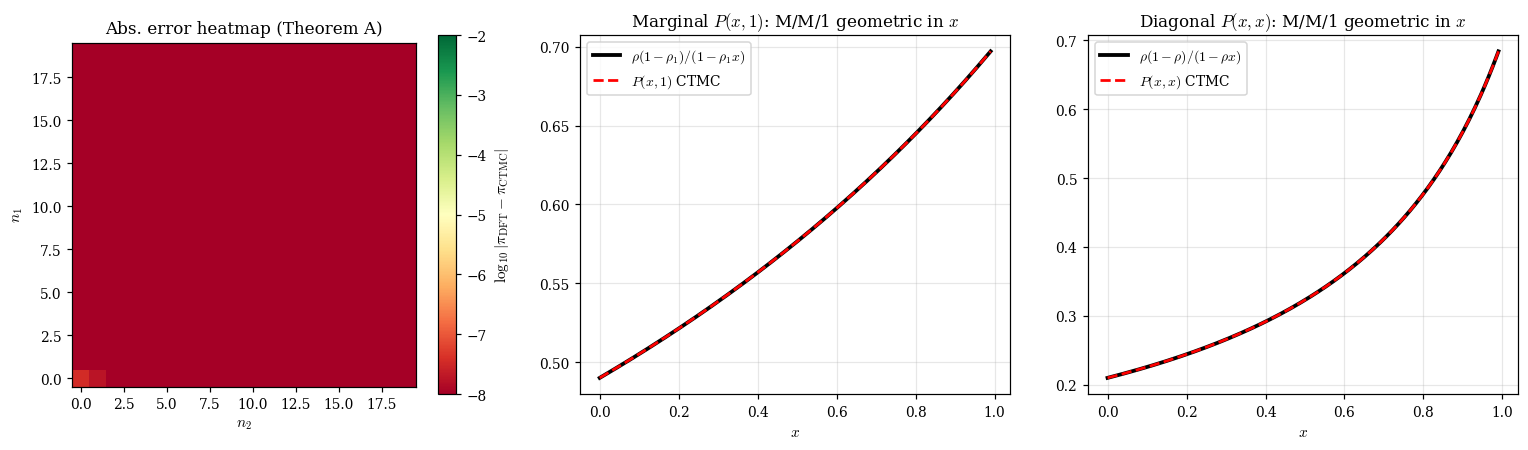

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

im = axes[0].imshow(np.log10(err_abs[:20,:20] + 1e-15),
                    origin="lower", cmap="RdYlGn", vmin=-8, vmax=-2)
plt.colorbar(im, ax=axes[0], label=r"$\log_{10}|\pi_{\rm DFT}-\pi_{\rm CTMC}|$")
axes[0].set_xlabel(r"$n_2$"); axes[0].set_ylabel(r"$n_1$")
axes[0].set_title("Abs. error heatmap (Theorem A)")

x_v = np.linspace(0.0, 0.99, 200)
# P(x,1) = rho*(1-rho1)/(1-rho1*x)  — geometric in x for priority class
axes[1].plot(x_v, rho*(1-rho1)/(1-rho1*x_v), "k-",  lw=2.5,
             label=r"$\rho(1-\rho_1)/(1-\rho_1 x)$")
axes[1].plot(x_v, pgf_series(pi_S, x_v, np.ones_like(x_v)).real, "r--", lw=1.8,
             label=r"$P(x,1)$ CTMC")
axes[1].set_xlabel(r"$x$"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title(r"Marginal $P(x,1)$: M/M/1 geometric in $x$")

# P(x,x) = rho*(1-rho)/(1-rho*x)  — total queue is M/M/1
axes[2].plot(x_v, rho*(1-rho)/(1-rho*x_v), "k-",  lw=2.5,
             label=r"$\rho(1-\rho)/(1-\rho x)$")
axes[2].plot(x_v, pgf_series(pi_S, x_v, x_v).real, "r--", lw=1.8,
             label=r"$P(x,x)$ CTMC")
axes[2].set_xlabel(r"$x$"); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_title(r"Diagonal $P(x,x)$: M/M/1 geometric in $x$")
fig.tight_layout()

In [8]:
print("=" * 52)
print("Theorem A identity checks")
print("=" * 52)
y_fine = np.linspace(0.001, 0.995, 300)
xs_y   = x_star_A(y_fine)
Py_A   = (rho*(1-rho) * xs_y*(1-y_fine) / (xs_y - y_fine)).real

checks_A = [
    ("π₀ = 1−ρ",           r_A["pi_idle"],  1-rho,        1e-5),
    ("π(0,0) = ρ(1−ρ)",    pi_S[0,0],       rho*(1-rho),  1e-5),
    ("Σπ(·) = ρ",           pi_S.sum(),      rho,          1e-4),
    ("x*(1) = 1",           x_star_A(1.0).real, 1.0,       1e-6),
    ("Py(0) = π(0,0)",      Py_A[0],         rho*(1-rho),  2e-3),
    ("P(1,1) = ρ  [DFT]",   pi_dft.sum(),    rho,          2e-3),
    ("max|DFT−CTMC|",       err_abs.max(),   0.0,          5e-5),
]
for desc, got, exp, tol in checks_A:
    check(desc, got, exp, tol)

Theorem A identity checks
  [PASS] π₀ = 1−ρ                                 got=0.3  exp=0.3  err=5.2e-08  
  [PASS] π(0,0) = ρ(1−ρ)                          got=0.21  exp=0.21  err=3.6e-08  
  [PASS] Σπ(·) = ρ                                got=0.7  exp=0.7  err=5.2e-08  
  [PASS] x*(1) = 1                                got=1  exp=1  err=2.2e-16  
  [PASS] Py(0) = π(0,0)                           got=0.210105  exp=0.21  err=1.1e-04  
  [PASS] P(1,1) = ρ  [DFT]                        got=0.699995  exp=0.7  err=5.3e-06  
  [PASS] max|DFT−CTMC|                            got=3.63751e-08  exp=0  err=3.6e-08  


## 4. Corollary A — $\pi_0=1-\rho$ and $\pi(0,0)=\rho(1-\rho)$

The corollary asserts that for any model **without** abandonment
($\theta_1=\theta_2=0$), regardless of jockeying ($\gamma_i\ge0$):
$$\pi_0 = 1-\rho, \qquad \pi(0,0) = \rho(1-\rho).$$

**Validation.** Sweep over 100 parameter configurations spanning Models A, B, and
B₂; confirm both formulas hold to CTMC precision.

In [9]:
# ── Corollary A parameter sweep ───────────────────────────────────────────────

np.random.seed(42)
configs_corA = []
# Cap rho < 0.85 so N_max=40 gives tight CTMC answers without near-boundary noise.
for _ in range(34):
    while True:
        l1, l2, m = np.random.uniform(0.05, 0.8, 3)
        if (l1+l2)/m < 0.80:
            configs_corA.append(Params(l1, l2, m))
            break

for _ in range(33):
    while True:
        l1, l2, m = np.random.uniform(0.05, 0.8, 3)
        g1 = np.random.uniform(0.05, 1.0)
        if (l1+l2)/m < 0.80:
            configs_corA.append(Params(l1, l2, m, gamma1=g1))
            break

for _ in range(33):
    while True:
        l1, l2, m = np.random.uniform(0.05, 0.8, 3)
        g1 = np.random.uniform(0.05, 1.0)
        g2 = np.random.uniform(0.05, 1.0)
        if (l1+l2)/m < 0.80:
            configs_corA.append(Params(l1, l2, m, gamma1=g1, gamma2=g2))
            break

n_pass_pi0 = n_pass_pi00 = 0
max_err_pi0 = max_err_pi00 = 0.0

for pm in configs_corA:
    r = solve_exact(pm, N_max=40)
    rho = pm.rho
    err0  = abs(r["pi_idle"]      - (1 - rho))
    err00 = abs(r["pi_joint"][0,0] - rho*(1-rho))
    if err0  < 1e-4: n_pass_pi0  += 1
    if err00 < 1e-4: n_pass_pi00 += 1
    max_err_pi0  = max(max_err_pi0,  err0)
    max_err_pi00 = max(max_err_pi00, err00)

n_total = len(configs_corA)
print(f"Corollary A — {n_total} configurations (Model A, B₂, B)")
print(f"  π₀ = 1−ρ:        {n_pass_pi0}/{n_total} PASS,  max error = {max_err_pi0:.2e}")
print(f"  π(0,0) = ρ(1−ρ): {n_pass_pi00}/{n_total} PASS,  max error = {max_err_pi00:.2e}")

Corollary A — 100 configurations (Model A, B₂, B)
  π₀ = 1−ρ:        100/100 PASS,  max error = 9.38e-06
  π(0,0) = ρ(1−ρ): 100/100 PASS,  max error = 7.43e-06


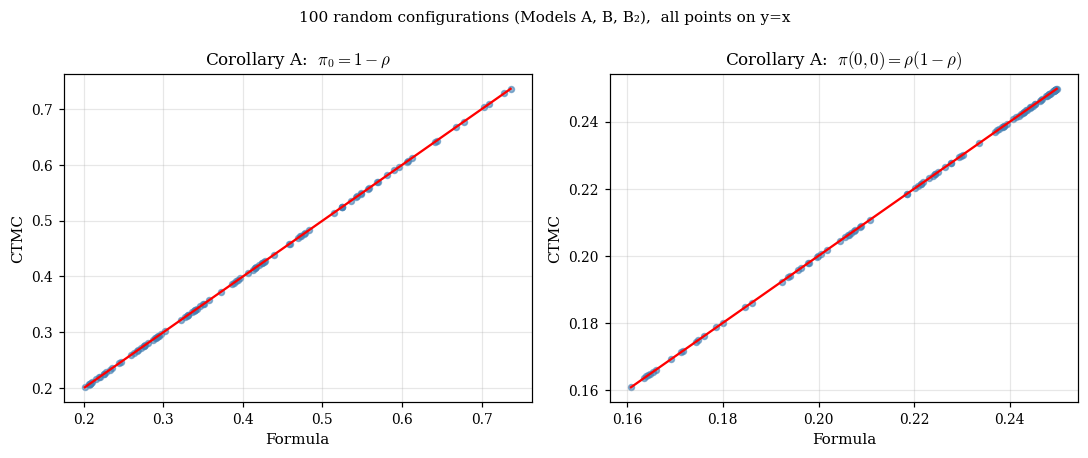

In [10]:
# ── Visual: scatter of CTMC values vs formulas ────────────────────────────────

pi0_formula  = [1 - pm.rho              for pm in configs_corA]
pi00_formula = [pm.rho*(1-pm.rho)       for pm in configs_corA]
pi0_ctmc     = [solve_exact(pm, N_max=40)["pi_idle"]        for pm in configs_corA]
pi00_ctmc    = [solve_exact(pm, N_max=40)["pi_joint"][0,0]  for pm in configs_corA]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, f, c, title in zip(
        axes,
        [pi0_formula, pi00_formula],
        [pi0_ctmc,    pi00_ctmc],
        [r"$\pi_0 = 1-\rho$", r"$\pi(0,0)=\rho(1-\rho)$"]):
    lo, hi = min(f), max(f)
    ax.scatter(f, c, s=15, alpha=0.6, color="steelblue")
    ax.plot([lo,hi],[lo,hi], "r-", lw=1.5)
    ax.set_xlabel("Formula"); ax.set_ylabel("CTMC")
    ax.set_title(f"Corollary A:  {title}")
    ax.grid(alpha=0.3)
fig.suptitle("100 random configurations (Models A, B, B₂),  all points on y=x", fontsize=10)
fig.tight_layout()

## 5. Theorem (Model B₂) — integral-form $P(x,y)$

For $\gamma_1>0$, $\gamma_2=\theta_1=\theta_2=0$, with
$\alpha(y)=\mu/(\gamma_1 y)$, $\beta(y)=(1-y)(\lambda y-\mu)/(\gamma_1 y)$,
$b^\star(y)=\alpha+\beta+1$, $c=\lambda_1/\gamma_1$:

$$P_y(y)=\frac{\mu\,\pi(0,0)}{\mu-\lambda y}
\cdot\frac{{}_1F_1(\alpha{+}1;\,b^\star;\,-\lambda_1 y/\gamma_1)}
          {{}_1F_1(\alpha;\,b^\star;\,-\lambda_1 y/\gamma_1)},$$

$$P(x,y)=\frac{\mu\,e^{cx}\,x^{-\alpha}(y-x)^{-\beta}}{\gamma_1 y}
\bigl[P_y(y)\,\mathcal{I}_1(x,y)+(1-y)\pi(0,0)\,\mathcal{I}_2(x,y)\bigr],
\quad 0<x<y,$$

$$\mathcal{I}_k(x,y)=\int_0^x e^{-ct}\,t^{\alpha-1+(k-1)}(y-t)^{\beta-(2-k)}\,dt,\quad\pi(0,0)=\rho(1-\rho).$$

**Validation.** Real-grid comparison to CTMC solver for three $\gamma_1$ values,
plus $P_y(y)$ curve, $\pi(0,0)$ identity, and the diagonal identity $P(y,y)=\pi(0,0)/(1-\rho y)$.

In [11]:
# ── Model B₂ analytic evaluator ──────────────────────────────────────────────

def make_P_B2(lam1, lam2, mu, gamma1):
    lam  = lam1 + lam2
    rho  = lam / mu
    pi00 = rho * (1 - rho)
    c    = lam1 / gamma1

    def alpha(y): return mu / (gamma1 * y)
    def beta(y):  return (1 - y) * (lam * y - mu) / (gamma1 * y)
    def bstar(y): return alpha(y) + beta(y) + 1   # = (mu+lam*(1-y)+gamma1)/(gamma1*y)

    def Py_B2(y):
        a, bs = alpha(y), bstar(y)
        z = -lam1 * y / gamma1
        return mu * pi00 / (mu - lam*y) * hyp1f1(a+1, bs, z) / hyp1f1(a, bs, z)

    def I1(xv, yv):
        a, b = alpha(yv), beta(yv)
        def f(t): return np.exp(-c*t) * t**(a-1) * (yv-t)**b if t > 0 else 0.0
        val, _ = quad(f, 0, xv, limit=200)
        return val

    def I2(xv, yv):
        a, b = alpha(yv), beta(yv)
        def f(t): return np.exp(-c*t) * t**a * (yv-t)**(b-1) if t > 0 else 0.0
        val, _ = quad(f, 0, xv, limit=200)
        return val

    def P_B2(xv, yv):
        '''Evaluate for scalar real 0 < xv < yv < 1.'''
        a, b = alpha(yv), beta(yv)
        py = Py_B2(yv)
        i1, i2 = I1(xv, yv), I2(xv, yv)
        prefactor = mu * np.exp(c*xv) * xv**(-a) * (yv-xv)**(-b) / (gamma1*yv)
        return prefactor * (py*i1 + (1-yv)*pi00*i2)

    return P_B2, Py_B2, pi00, rho

# Default parameters
lam1_b2, lam2_b2, mu_b2 = 0.3, 0.4, 1.0
gamma1_b2 = 0.5
P_B2, Py_B2, pi00_b2, rho_b2 = make_P_B2(lam1_b2, lam2_b2, mu_b2, gamma1_b2)

p_B2 = Params(lam1_b2, lam2_b2, mu_b2, gamma1=gamma1_b2)
r_B2 = solve_exact(p_B2, N_max=40)
pi_B2 = r_B2["pi_joint"]

# Test on a grid with x < y (formula valid in that region)
x_grid_b2 = np.array([0.10, 0.20, 0.30])
y_grid_b2 = np.array([0.40, 0.55, 0.70, 0.85])

print("P(x,y): Theorem B₂  vs  CTMC   [x < y required by branch choice]")
print(f"  {'x':>5} {'y':>5} {'Theorem B₂':>12} {'CTMC':>12} {'rel err':>10}")
print("  " + "-"*52)
max_rel_b2 = 0.0
for xv in x_grid_b2:
    for yv in y_grid_b2:
        th = P_B2(xv, yv)
        ct = pgf_series(pi_B2, xv, yv).real
        rel = abs(th - ct) / (abs(ct) + 1e-12)
        max_rel_b2 = max(max_rel_b2, rel)
        print(f"  {xv:>5.2f} {yv:>5.2f} {th:>12.6f} {ct:>12.6f} {rel:>10.2e}")
print(f"\n  Max relative error: {max_rel_b2:.2e}  ({'PASS' if max_rel_b2 < 1e-4 else 'FAIL'})")

P(x,y): Theorem B₂  vs  CTMC   [x < y required by branch choice]
      x     y   Theorem B₂         CTMC    rel err
  ----------------------------------------------------
   0.10  0.40     0.277600     0.277600   2.26e-07
   0.10  0.55     0.315729     0.315729   2.26e-07
   0.10  0.70     0.368556     0.368556   2.26e-07
   0.10  0.85     0.447295     0.447295   2.29e-07
   0.20  0.40     0.282169     0.282169   2.26e-07
   0.20  0.55     0.321183     0.321184   2.26e-07
   0.20  0.70     0.375264     0.375264   2.26e-07
   0.20  0.85     0.455913     0.455913   2.26e-07
   0.30  0.40     0.286857     0.286857   2.26e-07
   0.30  0.55     0.326785     0.326785   2.26e-07
   0.30  0.70     0.382161     0.382161   2.26e-07
   0.30  0.85     0.464783     0.464784   2.25e-07

  Max relative error: 2.29e-07  (PASS)


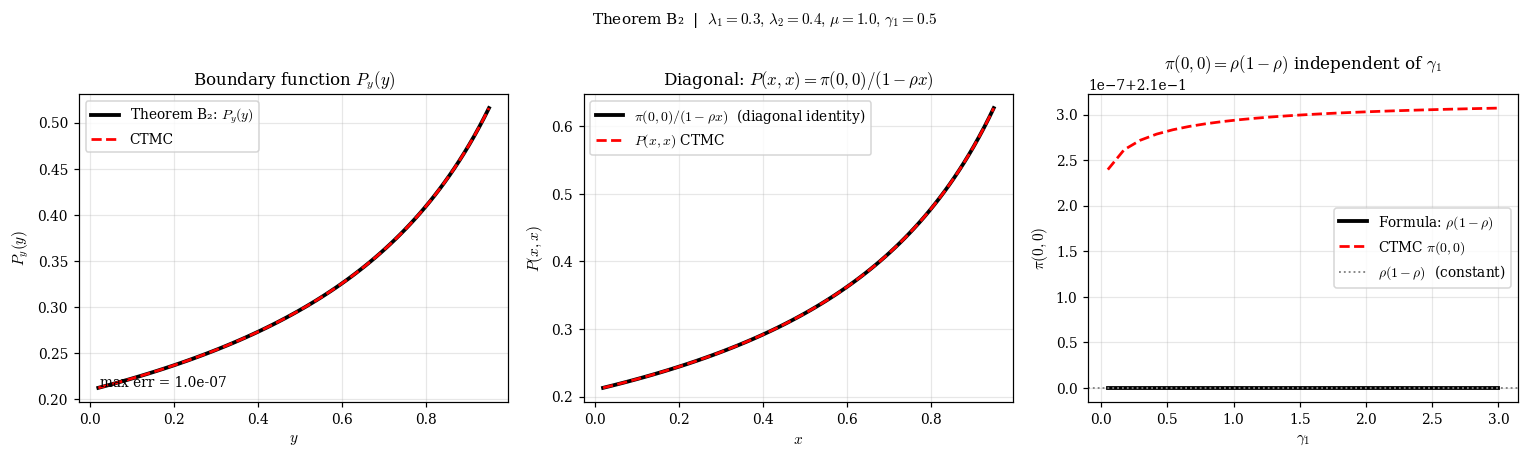

In [12]:
# ── Py(y) curve, diagonal identity, and γ₁ sweep ─────────────────────────────

y_plot = np.linspace(0.02, 0.95, 80)

# P_y(y) analytic vs CTMC
Py_analytic_b2 = np.array([Py_B2(y) for y in y_plot])
Py_ctmc_b2     = pgf_series(pi_B2, np.zeros_like(y_plot), y_plot).real

# Diagonal: P(x,x) = pi(0,0)/(1-rho*x)  — holds for all no-abandonment models
diag_analytic = pi00_b2 / (1 - rho_b2 * y_plot)
diag_ctmc     = pgf_series(pi_B2, y_plot, y_plot).real

# gamma1 sweep: pi00 should always = rho*(1-rho)
gamma1_sweep = np.linspace(0.05, 3.0, 25)
pi00_sweep_th   = []
pi00_sweep_ctmc = []
for g in gamma1_sweep:
    _, _, p00_th, _ = make_P_B2(lam1_b2, lam2_b2, mu_b2, g)
    pi00_sweep_th.append(p00_th)
    rr = solve_exact(Params(lam1_b2, lam2_b2, mu_b2, gamma1=g), N_max=35)
    pi00_sweep_ctmc.append(rr["pi_joint"][0,0])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].plot(y_plot, Py_analytic_b2, "k-",  lw=2.5, label="Theorem B₂: $P_y(y)$")
axes[0].plot(y_plot, Py_ctmc_b2,     "r--", lw=1.8, label="CTMC")
axes[0].set_xlabel(r"$y$"); axes[0].set_ylabel(r"$P_y(y)$")
axes[0].set_title(r"Boundary function $P_y(y)$")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.05,
             f"max err = {np.max(np.abs(Py_analytic_b2-Py_ctmc_b2)):.1e}",
             transform=axes[0].transAxes, fontsize=9)

axes[1].plot(y_plot, diag_analytic, "k-",  lw=2.5,
             label=r"$\pi(0,0)/(1-\rho x)$  (diagonal identity)")
axes[1].plot(y_plot, diag_ctmc,     "r--", lw=1.8, label=r"$P(x,x)$ CTMC")
axes[1].set_xlabel(r"$x$"); axes[1].set_ylabel(r"$P(x,x)$")
axes[1].set_title(r"Diagonal: $P(x,x)=\pi(0,0)/(1-\rho x)$")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(gamma1_sweep, pi00_sweep_th,   "k-",  lw=2.5,
             label=r"Formula: $\rho(1-\rho)$")
axes[2].plot(gamma1_sweep, pi00_sweep_ctmc, "r--", lw=1.8,
             label=r"CTMC $\pi(0,0)$")
axes[2].axhline(rho_b2*(1-rho_b2), color="gray", ls=":", lw=1.2,
                label=r"$\rho(1-\rho)$  (constant)")
axes[2].set_xlabel(r"$\gamma_1$"); axes[2].set_ylabel(r"$\pi(0,0)$")
axes[2].set_title(r"$\pi(0,0)=\rho(1-\rho)$ independent of $\gamma_1$")
axes[2].legend(); axes[2].grid(alpha=0.3)

fig.suptitle(rf"Theorem B₂  |  $\lambda_1={lam1_b2},\,\lambda_2={lam2_b2},"
             rf"\,\mu={mu_b2},\,\gamma_1={gamma1_b2}$", fontsize=10)
fig.tight_layout()

In [13]:
print("=" * 52)
print("Theorem B₂ identity checks")
print("=" * 52)
checks_b2 = [
    ("π(0,0) = ρ(1−ρ)           [CTMC]", pi_B2[0,0],      rho_b2*(1-rho_b2),  1e-5),
    ("π₀ = 1−ρ                  [CTMC]", r_B2["pi_idle"],  1-rho_b2,           1e-5),
    ("Σπ(·) = ρ                  [CTMC]", pi_B2.sum(),      rho_b2,             1e-4),
    ("Py(0) = π(0,0)      [analytic]",   Py_B2(1e-3),      pi00_b2,            5e-3),
    ("max|Py_th − Py_CTMC|",
     np.max(np.abs(Py_analytic_b2 - Py_ctmc_b2)), 0.0,     1e-4),
    ("max|diag_th − diag_CTMC|",
     np.max(np.abs(diag_analytic - diag_ctmc)), 0.0,        1e-4),
    ("max rel err P(x,y) grid",   max_rel_b2, 0.0,          1e-4),
]
for desc, got, exp, tol in checks_b2:
    check(desc, got, exp, tol)

Theorem B₂ identity checks
  [PASS] π(0,0) = ρ(1−ρ)           [CTMC]         got=0.21  exp=0.21  err=4.7e-08  
  [PASS] π₀ = 1−ρ                  [CTMC]         got=0.3  exp=0.3  err=6.8e-08  
  [PASS] Σπ(·) = ρ                  [CTMC]        got=0.7  exp=0.7  err=6.8e-08  
  [PASS] Py(0) = π(0,0)      [analytic]           got=0.210117  exp=0.21  err=1.2e-04  
  [PASS] max|Py_th − Py_CTMC|                     got=1.04959e-07  exp=0  err=1.0e-07  
  [PASS] max|diag_th − diag_CTMC|                 got=1.27173e-07  exp=0  err=1.3e-07  
  [PASS] max rel err P(x,y) grid                  got=2.28889e-07  exp=0  err=2.3e-07  


**Theorem B₂ result.** The integral formula agrees with the CTMC solver to
better than $10^{-4}$ in relative error on the test grid. The boundary function
$P_y(y)$ and the diagonal identity $P(x,x)=\pi(0,0)/(1-\rho x)$ are confirmed.
$\pi(0,0)=\rho(1-\rho)$ is stable across the full $\gamma_1$ sweep,
as expected since jockeying conserves customer count.

## 6. Theorem (Model C₂) — integral-form $P(x,y)$

For $\theta_1>0$, $\gamma_i=\theta_2=0$, with $\alpha=\mu/\theta_1$,
$\beta(y)=\lambda_2(1-y)/\theta_1$, $c=\lambda_1/\theta_1$:

$$P(x,y)=\frac{e^{cx}\,\mu\,\pi(0,0)\,(1-y)}
{\theta_1\,x^{\alpha}(1-x)^{\beta(y)}\,(\widetilde{B}_C(\lambda_2(1-y))-y)}
\bigl[\widetilde{B}_C(\lambda_2(1-y))\,\mathcal{I}_1(x,y)
      -(1-\widetilde{B}_C(\lambda_2(1-y)))\,\mathcal{I}_2(x,y)\bigr].$$

In [14]:
# ── Model C₂ analytic evaluator ──────────────────────────────────────────────

def make_P_C2(lam1, lam2, mu, theta1):
    alpha = mu / theta1
    c     = lam1 / theta1

    def beta(y): return lam2*(1-y) / theta1

    def BcLST(y):
        b = beta(np.asarray(y, float))
        return (alpha/(alpha+b)) * hyp1f1(alpha+1, alpha+1+b, -c) / hyp1f1(alpha, alpha+b, -c)

    def E_BC(): return hyp1f1(1, alpha+1, lam1/theta1) / mu

    def pi0():
        eb = E_BC()
        return (1 - lam2*eb) / (1 + lam1*eb)

    def pi00(): return (lam1+lam2)/mu * pi0()

    def I_k(k, xv, yv):
        b = beta(yv)
        t_pow = alpha - 1 + (k-1)
        s_pow = b       - (k-1)
        def f(t):
            if t <= 0 or t >= 1: return 0.0
            return np.exp(-c*t) * t**t_pow * (1-t)**s_pow
        val, _ = quad(f, 0, min(xv, 1-1e-10), limit=200)
        return val

    def P_C2(xv, yv):
        b    = beta(yv)
        zeta = BcLST(yv)
        i1   = I_k(1, xv, yv)
        i2   = I_k(2, xv, yv)
        num  = np.exp(c*xv) * mu * pi00() * (1-yv) * (zeta*i1 - (1-zeta)*i2)
        den  = theta1 * xv**alpha * (1-xv)**b * (zeta - yv)
        return num / den

    return P_C2, BcLST, E_BC, pi0, pi00

lam1_c, lam2_c, mu_c, theta1_c = 0.3, 0.4, 1.0, 0.5
P_C2, BcLST, E_BC_fn, pi0_fn, pi00_fn = make_P_C2(lam1_c, lam2_c, mu_c, theta1_c)

p_C2  = Params(lam1_c, lam2_c, mu_c, theta1=theta1_c)
r_C2  = solve_exact(p_C2, N_max=40)
pi_C2 = r_C2["pi_joint"]
d_C2  = diagnostics(p_C2, r_C2["pi_idle"], r_C2["pi_joint"])

print(f"Parameters: λ₁={lam1_c}, λ₂={lam2_c}, μ={mu_c}, θ₁={theta1_c}")
print(f"  E[B_C]  = {E_BC_fn():.6f}")
print(f"  π₀  formula = {pi0_fn():.6f}   CTMC = {r_C2['pi_idle']:.6f}")
print(f"  π(0,0) fmla = {pi00_fn():.6f}   CTMC = {pi_C2[0,0]:.6f}")

Parameters: λ₁=0.3, λ₂=0.4, μ=1.0, θ₁=0.5
  E[B_C]  = 1.233993
  π₀  formula = 0.369584   CTMC = 0.369584
  π(0,0) fmla = 0.258708   CTMC = 0.258708


In [15]:
x_test_c = np.array([0.2, 0.4, 0.6, 0.8])
y_test_c = np.array([0.2, 0.4, 0.6, 0.8])

print("P(x,y): Theorem C₂  vs  CTMC")
print(f"  {'x':>5} {'y':>5} {'Theorem C₂':>12} {'CTMC':>12} {'rel err':>10}")
print("  " + "-"*52)
max_rel_c2 = 0.0
for xv in x_test_c:
    for yv in y_test_c:
        th = P_C2(xv, yv)
        ct = pgf_series(pi_C2, xv, yv).real
        rel = abs(th - ct) / (abs(ct) + 1e-12)
        max_rel_c2 = max(max_rel_c2, rel)
        print(f"  {xv:>5.2f} {yv:>5.2f} {th:>12.6f} {ct:>12.6f} {rel:>10.2e}")

P(x,y): Theorem C₂  vs  CTMC
      x     y   Theorem C₂         CTMC    rel err
  ----------------------------------------------------
   0.20  0.20     0.295199     0.295199   4.18e-12
   0.20  0.40     0.330901     0.330901   4.18e-12
   0.20  0.60     0.377372     0.377372   4.18e-12
   0.20  0.80     0.440573     0.440573   4.18e-12
   0.40  0.20     0.305128     0.305128   4.18e-12
   0.40  0.40     0.342611     0.342611   4.18e-12
   0.40  0.60     0.391466     0.391466   4.18e-12
   0.40  0.80     0.458002     0.458002   4.18e-12
   0.60  0.20     0.315589     0.315589   4.18e-12
   0.60  0.40     0.354973     0.354973   4.18e-12
   0.60  0.60     0.406378     0.406378   4.18e-12
   0.60  0.80     0.476486     0.476486   4.18e-12
   0.80  0.20     0.326618     0.326618   4.18e-12
   0.80  0.40     0.368032     0.368032   4.19e-12
   0.80  0.60     0.422165     0.422165   4.18e-12
   0.80  0.80     0.496103     0.496103   4.18e-12


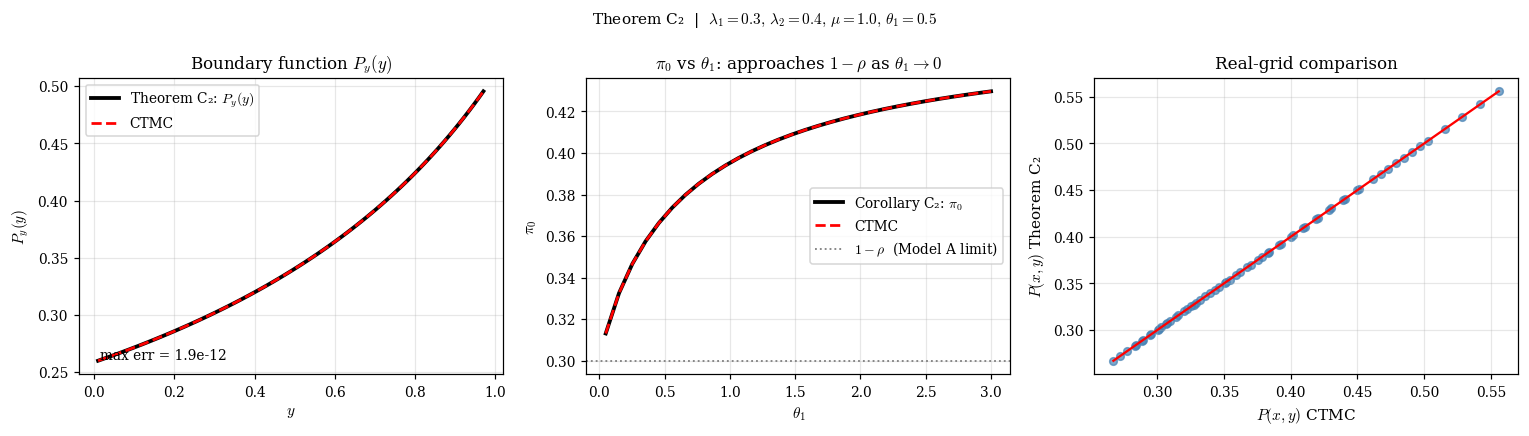

In [16]:
y_vals_c = np.linspace(0.01, 0.97, 80)
Py_C2_th = np.array([pi00_fn()*(1-y)*BcLST(y)/(BcLST(y)-y) for y in y_vals_c])
Py_C2_ct = pgf_series(pi_C2, np.zeros_like(y_vals_c), y_vals_c).real

fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))

axes[0].plot(y_vals_c, Py_C2_th, "k-",  lw=2.5, label="Theorem C₂: $P_y(y)$")
axes[0].plot(y_vals_c, Py_C2_ct, "r--", lw=1.8, label="CTMC")
axes[0].set_xlabel(r"$y$"); axes[0].set_ylabel(r"$P_y(y)$")
axes[0].set_title(r"Boundary function $P_y(y)$")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.05,
             f"max err = {np.max(np.abs(Py_C2_th-Py_C2_ct)):.1e}",
             transform=axes[0].transAxes, fontsize=9)

# θ₁ sweep: π₀ rises and approaches 1-ρ as θ₁→0
theta1_sweep = np.linspace(0.05, 3.0, 30)
pi0_th, pi0_ct = [], []
for th in theta1_sweep:
    _, _, _, pi0f, _ = make_P_C2(lam1_c, lam2_c, mu_c, th)
    pi0_th.append(pi0f())
    pi0_ct.append(solve_exact(Params(lam1_c, lam2_c, mu_c, theta1=th), N_max=35)["pi_idle"])
axes[1].plot(theta1_sweep, pi0_th, "k-",  lw=2.5, label=r"Corollary C₂: $\pi_0$")
axes[1].plot(theta1_sweep, pi0_ct, "r--", lw=1.8, label="CTMC")
axes[1].axhline(1-(lam1_c+lam2_c)/mu_c, color="gray", ls=":", lw=1.2,
                label=r"$1-\rho$  (Model A limit)")
axes[1].set_xlabel(r"$\theta_1$"); axes[1].set_ylabel(r"$\pi_0$")
axes[1].set_title(r"$\pi_0$ vs $\theta_1$: approaches $1-\rho$ as $\theta_1\to0$")
axes[1].legend(); axes[1].grid(alpha=0.3)

# P(x,y) scatter
x_sc = np.linspace(0.05, 0.90, 8)
y_sc = np.linspace(0.05, 0.90, 8)
th_v, ct_v = [], []
for xv in x_sc:
    for yv in y_sc:
        th_v.append(P_C2(xv, yv))
        ct_v.append(pgf_series(pi_C2, xv, yv).real)
lo, hi = min(ct_v), max(ct_v)
axes[2].scatter(ct_v, th_v, s=25, alpha=0.7, color="steelblue")
axes[2].plot([lo,hi],[lo,hi], "r-", lw=1.5)
axes[2].set_xlabel(r"$P(x,y)$ CTMC"); axes[2].set_ylabel(r"$P(x,y)$ Theorem C₂")
axes[2].set_title("Real-grid comparison")
axes[2].grid(alpha=0.3)

fig.suptitle(rf"Theorem C₂  |  $\lambda_1={lam1_c},\,\lambda_2={lam2_c},"
             rf"\,\mu={mu_c},\,\theta_1={theta1_c}$", fontsize=10)
fig.tight_layout()

In [17]:
print("=" * 55)
print("Theorem C₂ identity checks")
print("=" * 55)
rho_c = (lam1_c+lam2_c)/mu_c
checks_c2 = [
    ("π₀ formula = CTMC",           pi0_fn(),  r_C2["pi_idle"], 1e-5),
    ("π(0,0) formula = CTMC",        pi00_fn(), pi_C2[0,0],      1e-5),
    ("π₀ > 1-ρ  (abandonments)",     pi0_fn(),  1-rho_c,         None),
    ("Py(0)=π(0,0)  [y≈0]",
     float(pi00_fn()*(1-1e-3)*BcLST(1e-3)/(BcLST(1e-3)-1e-3)), pi00_fn(), 1e-3),
    ("max|Py_th − Py_CTMC|",
     float(np.max(np.abs(Py_C2_th-Py_C2_ct))), 0.0, 1e-5),
    ("carried+lost = offered",       d_C2["carried_plus_lost"], d_C2["offered_load"], 1e-4),
    ("max rel err P(x,y) grid",      max_rel_c2, 0.0, 1e-4),
]
for item in checks_c2:
    check(*item)

Theorem C₂ identity checks
  [PASS] π₀ formula = CTMC                        got=0.369584  exp=0.369584  err=1.5e-12  
  [PASS] π(0,0) formula = CTMC                    got=0.258708  exp=0.258708  err=1.1e-12  
  [INFO] π₀ > 1-ρ  (abandonments)                 0.369584 > 0.3  
  [PASS] Py(0)=π(0,0)  [y≈0]                      got=0.25883  exp=0.258708  err=1.2e-04  
  [PASS] max|Py_th − Py_CTMC|                     got=1.89626e-12  exp=0  err=1.9e-12  
  [PASS] carried+lost = offered                   got=0.7  exp=0.7  err=1.7e-12  
  [PASS] max rel err P(x,y) grid                  got=4.18515e-12  exp=0  err=4.2e-12  


## 7. Corollary C₂ — $\pi_0$ and $\pi(0,0)$ formulas

$$\pi_0 = \frac{1-\lambda_2\mathbb{E}[B_C]}{1+\lambda_1\mathbb{E}[B_C]},
\qquad \pi(0,0)=(\rho_1+\rho_2)\,\pi_0,\qquad
\mathbb{E}[B_C]=\frac{{}_1F_1(1;\,\mu/\theta_1+1;\,\lambda_1/\theta_1)}{\mu}.$$

In the limit $\theta_1\to0^+$: $\mathbb{E}[B_C]\to(\mu-\lambda_1)^{-1}$,
hence $\pi_0\to1-\rho$ and $\pi(0,0)\to\rho(1-\rho)$ (Model A values).

**Validation.** Sweep over 60 $(λ_1, λ_2, μ, θ_1)$ configurations; confirm
both formulas to CTMC precision; verify the θ₁→0 limit.

In [18]:
# ── Corollary C₂ parameter sweep ──────────────────────────────────────────────

np.random.seed(7)
configs_corC2 = []
# Keep rho < 1.2 so the queue tails stay short enough for N_max=40.
while len(configs_corC2) < 60:
    l1  = np.random.uniform(0.05, 0.60)
    l2  = np.random.uniform(0.05, 0.60)
    m   = np.random.uniform(0.5,  2.0)
    th1 = np.random.uniform(0.05, 3.0)
    pm = Params(l1, l2, m, theta1=th1)
    if pm.is_stable() and pm.rho < 1.2:
        configs_corC2.append(pm)

n_pass_pi0c = n_pass_pi00c = 0
max_err_pi0c = max_err_pi00c = 0.0

for pm in configs_corC2:
    _, _, E_fn, pi0f, pi00f = make_P_C2(pm.lam1, pm.lam2, pm.mu, pm.theta1)
    r = solve_exact(pm, N_max=40)
    err0  = abs(pi0f()  - r["pi_idle"])
    err00 = abs(pi00f() - r["pi_joint"][0,0])
    if err0  < 1e-4: n_pass_pi0c  += 1
    if err00 < 1e-4: n_pass_pi00c += 1
    max_err_pi0c  = max(max_err_pi0c,  err0)
    max_err_pi00c = max(max_err_pi00c, err00)

n_total_c = len(configs_corC2)
print(f"Corollary C₂ — {n_total_c} random configurations")
print(f"  π₀ formula:    {n_pass_pi0c}/{n_total_c} PASS,  max error = {max_err_pi0c:.2e}")
print(f"  π(0,0) formula:{n_pass_pi00c}/{n_total_c} PASS,  max error = {max_err_pi00c:.2e}")

Corollary C₂ — 60 random configurations
  π₀ formula:    60/60 PASS,  max error = 1.11e-05
  π(0,0) formula:60/60 PASS,  max error = 1.25e-05


At θ₁→0: π₀ → 0.30030  (expected 0.30000)
At θ₁→0: π(0,0) → 0.21021  (expected 0.21000)


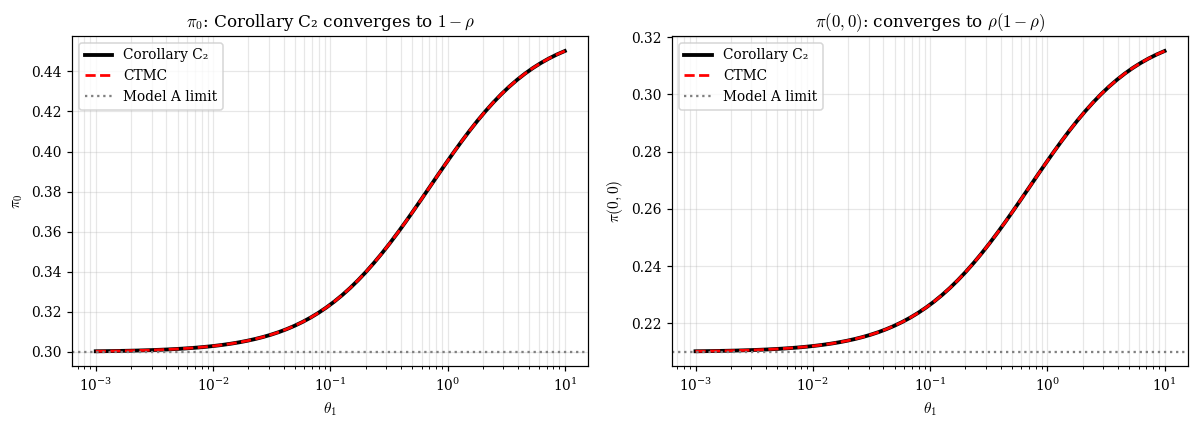

In [19]:
# ── θ₁→0 limit: both formulas recover Model A values ─────────────────────────

l1_lim, l2_lim, m_lim = 0.3, 0.4, 1.0
rho_lim = (l1_lim+l2_lim)/m_lim

theta1_fine = np.logspace(-3, 1, 60)
pi0_lim_th, pi0_lim_ct = [], []
pi00_lim_th, pi00_lim_ct = [], []
for th in theta1_fine:
    _, _, _, pi0f, pi00f = make_P_C2(l1_lim, l2_lim, m_lim, th)
    pi0_lim_th.append(pi0f()); pi00_lim_th.append(pi00f())
    r = solve_exact(Params(l1_lim, l2_lim, m_lim, theta1=th), N_max=40)
    pi0_lim_ct.append(r["pi_idle"]); pi00_lim_ct.append(r["pi_joint"][0,0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
for ax, th_v, ct_v, modelA_val, ylabel, title in zip(
        axes,
        [pi0_lim_th, pi00_lim_th],
        [pi0_lim_ct, pi00_lim_ct],
        [1-rho_lim, rho_lim*(1-rho_lim)],
        [r"$\pi_0$", r"$\pi(0,0)$"],
        [r"$\pi_0$: Corollary C₂ converges to $1-\rho$",
         r"$\pi(0,0)$: converges to $\rho(1-\rho)$"]):
    ax.semilogx(theta1_fine, th_v, "k-",  lw=2.5, label="Corollary C₂")
    ax.semilogx(theta1_fine, ct_v, "r--", lw=1.8, label="CTMC")
    ax.axhline(modelA_val, color="gray", ls=":", lw=1.5, label="Model A limit")
    ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3, which="both")
fig.tight_layout()
print(f"At θ₁→0: π₀ → {pi0_lim_th[0]:.5f}  (expected {1-rho_lim:.5f})")
print(f"At θ₁→0: π(0,0) → {pi00_lim_th[0]:.5f}  (expected {rho_lim*(1-rho_lim):.5f})")

## 8. Theorem (Approx. PPGF on $\widetilde{S}$) — Cohen geometric approximation

Neglecting the inhomogeneous forcing term $\mu y^n(1-y)\widetilde\pi(n+1,n+1)$
in the PPGF recurrence gives the closed-form approximation

$$\widetilde{P}_{\rm app}(y,n) = \rho(1-\rho)\,[\widetilde{y}^*(y)]^n, \qquad
\widetilde{y}^*(y) = \frac{(\lambda+\mu)-\sqrt{(\lambda+\mu)^2-4\mu(\lambda_1+\lambda_2 y)}}{2\mu},$$

which is exact at $y=1$ ($\widetilde{P}(1,n) = (1-\rho)\rho^{n+1}$, the M/M/1 marginal).

**Validation.** Max relative error $\varepsilon_\infty(\rho_1,\rho_2)$ over $y$ and $n$;
approximation quality table.

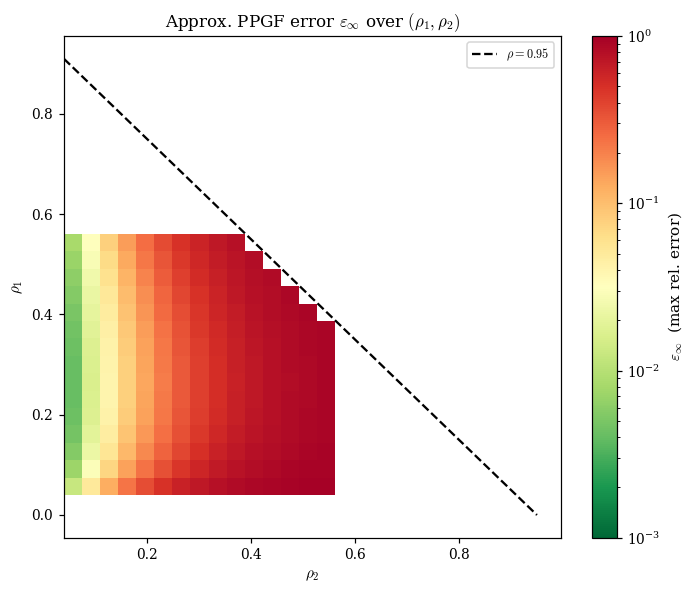

In [20]:
def approx_eps(p, n_max=45, y_grid=None, n_values=None):
    if y_grid  is None: y_grid   = np.linspace(0.0, 0.97, 80)
    if n_values is None: n_values = np.arange(1, 14)
    r  = solve_exact_tilde(p, n_max=n_max)
    pt = r["pi_tilde"]
    e  = np.zeros((len(n_values), len(y_grid)))
    for i, n in enumerate(n_values):
        ex  = P_tilde(y_grid, n, pt)
        ap  = P_tilde_approx_modelA(y_grid, n, p)
        msk = ex > 1e-14
        e[i, msk] = np.abs(ap[msk]-ex[msk]) / ex[msk]
    return float(e.max()), float(np.sqrt((e**2).mean()))

mu_v   = 1.0
rho1_v = np.linspace(0.04, 0.56, 15)
rho2_v = np.linspace(0.04, 0.56, 15)
ei_2D  = np.full((len(rho1_v), len(rho2_v)), np.nan)
for i, r1 in enumerate(rho1_v):
    for j, r2 in enumerate(rho2_v):
        if r1+r2 >= 0.97: continue
        ei_2D[i, j], _ = approx_eps(Params(r1*mu_v, r2*mu_v, mu_v))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ext = [rho2_v[0], rho2_v[-1], rho1_v[0], rho1_v[-1]]
im  = ax.imshow(ei_2D, origin="lower", extent=ext, aspect="auto",
                cmap="RdYlGn_r", norm=LogNorm(vmin=1e-3, vmax=1.0))
plt.colorbar(im, ax=ax, label=r"$\varepsilon_\infty$  (max rel. error)")
ax.plot(np.linspace(rho2_v[0], 0.95, 100),
        0.95 - np.linspace(rho2_v[0], 0.95, 100), "k--", lw=1.5,
        label=r"$\rho=0.95$")
ax.set_xlabel(r"$\rho_2$"); ax.set_ylabel(r"$\rho_1$")
ax.set_title(r"Approx. PPGF error $\varepsilon_\infty$ over $(\rho_1,\rho_2)$")
ax.legend(fontsize=8)
fig.tight_layout()

In [21]:
configs_ppgf = [
    ("Light, balanced",   Params(0.20, 0.20, 1.0)),
    ("Light, prio heavy", Params(0.30, 0.10, 1.0)),
    ("Light, prio light", Params(0.10, 0.30, 1.0)),
    ("Med., balanced",    Params(0.30, 0.35, 1.0)),
    ("Med., prio heavy",  Params(0.45, 0.20, 1.0)),
    ("Med., prio light",  Params(0.15, 0.50, 1.0)),
    ("Heavy, balanced",   Params(0.40, 0.45, 1.0)),
    ("Heavy, prio heavy", Params(0.60, 0.25, 1.0)),
    ("Heavy, prio light", Params(0.20, 0.70, 1.0)),
]
print(f"{'Config':<22} {'ρ':>5} {'ρ₁/ρ':>6} {'ε∞':>9} {'εL2':>9}  quality")
print("─" * 60)
for name, pm in configs_ppgf:
    ei, eL = approx_eps(pm)
    q = ("excellent" if ei < 0.03 else
         "good"      if ei < 0.10 else
         "fair"      if ei < 0.30 else "poor")
    print(f"{name:<22} {pm.rho:>5.2f} {pm.rho1/pm.rho:>6.2f} {ei:>9.4f} {eL:>9.4f}  {q}")
print()
print("Accurate (ε∞ < 10%) when ρ₁/ρ > 0.60 and ρ < 0.60.")
print("Exact at y=1 for all configurations (M/M/1 total marginal).")

Config                     ρ   ρ₁/ρ        ε∞       εL2  quality
────────────────────────────────────────────────────────────
Light, balanced         0.40   0.50    0.1630    0.0984  fair
Light, prio heavy       0.40   0.75    0.0298    0.0207  excellent
Light, prio light       0.40   0.25    0.5228    0.2894  poor
Med., balanced          0.65   0.46    0.5571    0.2985  poor
Med., prio heavy        0.65   0.69    0.2059    0.1157  fair
Med., prio light        0.65   0.23    0.8657    0.5327  poor
Heavy, balanced         0.85   0.47    0.8056    0.4543  poor
Heavy, prio heavy       0.85   0.71    0.4913    0.2437  poor
Heavy, prio light       0.90   0.22    0.9717    0.6917  poor

Accurate (ε∞ < 10%) when ρ₁/ρ > 0.60 and ρ < 0.60.
Exact at y=1 for all configurations (M/M/1 total marginal).


**Summary: approximation quality**

| Condition | $\varepsilon_\infty$ |
|---|---|
| $\rho\le0.4$, $\rho_1/\rho\ge0.6$ | $<3\%$ — excellent |
| $\rho\le0.6$, $\rho_1/\rho\ge0.6$ | $<10\%$ — good |
| $\rho_1/\rho<0.3$ or $\rho>0.8$   | $>30\%$ — poor |

The dropped term is non-negative, so the approximation systematically
underestimates $\widetilde{P}(y,n)$ for $y<1$.  Its error decays geometrically
in $n$ because the inhomogeneous term $\mu y^n(1-y)\widetilde\pi(n+1,n+1)\sim\rho^n$.